In [57]:
import yfinance as yf
import matplotlib.pyplot as plt

In [58]:
data = yf.Ticker("QQQ").history("5y")
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2017-10-11,142.577697,143.099578,142.394073,143.070572,12439100,0.0,0
2017-10-12,142.857925,143.370133,142.664627,142.809601,14513500,0.0,0
2017-10-13,143.389450,143.524750,142.819259,143.360458,18409900,0.0,0
2017-10-16,143.718048,143.891999,143.408783,143.853348,21809400,0.0,0
2017-10-17,143.805053,144.056320,143.582778,144.036987,13138200,0.0,0


In [59]:
def MACD(data):
    data['EMA12'] = data.Close.ewm(span=12).mean()
    data['EMA26'] = data.Close.ewm(span=26).mean()
    data['MACD']  = data.EMA12 - data.EMA26
    data['signal']= data.MACD.ewm(span=9).mean()
    print('indicators added')
    
data.head(MACD(data))

indicators added


,Open,High,Low,Close,Volume,Dividends,Stock Splits,EMA12,EMA26,MACD,signal
Date,,,,,,,,,,,
2017-10-11,142.577697,143.099578,142.394073,143.070572,12439100,0.0,0,143.070572,143.070572,0.000000,0.000000
2017-10-12,142.857925,143.370133,142.664627,142.809601,14513500,0.0,0,142.929213,142.935068,-0.005855,-0.003253
2017-10-13,143.389450,143.524750,142.819259,143.360458,18409900,0.0,0,143.097528,143.087906,0.009621,0.002024
2017-10-16,143.718048,143.891999,143.408783,143.853348,21809400,0.0,0,143.336111,143.301890,0.034220,0.012930
2017-10-17,143.805053,144.056320,143.582778,144.036987,13138200,0.0,0,143.526536,143.472362,0.054174,0.025199
...,...,...,...,...,...,...,...,...,...,...,...
2022-10-05,278.279999,283.809998,275.420013,281.980011,55766300,0.0,0,279.913370,287.330254,-7.416883,-7.907589
2022-10-06,280.959991,284.179993,279.429993,279.760010,53489400,0.0,0,279.889776,286.769495,-6.879718,-7.702015
2022-10-07,275.019989,275.149994,267.739990,269.100006,71263400,0.0,0,278.229812,285.460644,-7.230832,-7.607778


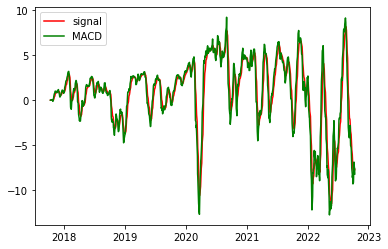

In [60]:
plt.plot(data.signal, label='signal', color='red')
plt.plot(data.MACD, label='MACD', color='green')
plt.legend()
plt.show()

In [61]:
Buy, Sell = [], []

for i in range(3, len(data)):
#dadurch prüft code für jede Zeile zwischen 2 und ende des datensatzes ob die IF-Statements stimmen    
    
    if data.MACD.iloc[i] > data.signal.iloc[i] and data.MACD.iloc[i-1] < data.signal.iloc[i-1]:
        Buy.append(i)
        # 'iloc' gibt die location von i an. I sind die Zeilen des Datensatzes. 
        # Wenn also MACD in Zeile i GRÖ?ER ist als Signal in Zeile I UND 
        # in der Zeile davor also am Tag davor (i-1) Signal GRÖ?ER war als MACD wird gekauft
    
    if data.MACD.iloc[i] < data.signal.iloc[i] and data.MACD.iloc[i-1] > data.signal.iloc[i-1]:
        Sell.append(i)
        # 'iloc' gibt die location von i an. I sind die Zeilen des Datensatzes. 
        # Wenn also MACD in Zeile i KLEINER ist als Signal in Zeile I UND 
        # in der Zeile davor also am Tag davor (i-1) Signal KLEINER war als MACD wird gekauft

In [62]:
Buy
#zeigt an in welchen Reihen ein Buy signal vorliegt

[12,
 29,
 44,
 57,
 89,
 125,
 135,
 186,
 206,
 220,
 242,
 268,
 277,
 285,
 307,
 309,
 357,
 369,
 415,
 467,
 473,
 503,
 536,
 547,
 582,
 617,
 653,
 662,
 678,
 686,
 696,
 707,
 716,
 747,
 773,
 801,
 823,
 834,
 860,
 909,
 952,
 973,
 1009,
 1059,
 1085,
 1102,
 1114,
 1163,
 1183,
 1254]

In [63]:
#zeigt an wie viele Buy signals vorliegen
number = sum(1 for line in Buy)
print(number)

50


In [64]:
Sell
#zeigt an in welcher Zeile ein Sell signal vorliegt
#zeigt, dass Probleme auftreten können weiter unten.
#hier wird nur die LONG-Strategie getestet. Da wir ein Sell-signal in Zeile 8 haben
#und ein Buy Signal erst in Zeile 12, wird das einen Fehler rausschmeißen
#daher codezeile 50 einbauen

[8,
 28,
 34,
 53,
 77,
 108,
 134,
 174,
 199,
 210,
 227,
 247,
 276,
 279,
 296,
 308,
 346,
 365,
 388,
 444,
 469,
 490,
 531,
 538,
 575,
 593,
 651,
 660,
 670,
 679,
 695,
 698,
 712,
 730,
 763,
 798,
 806,
 830,
 843,
 890,
 946,
 953,
 985,
 1037,
 1066,
 1097,
 1107,
 1131,
 1175,
 1222,
 1257]

In [68]:
#Indikatoren werden ja anhand der Close prices berechnet. D.h. um zu kaufen und zu verkaufen
#werden erst am Openprice des Folgetages möglich

#außerdem wichtig zu beachten. Es wird ein Fehler rausgeschmissen ohne die Endung: "and range(3,1257)"
#das liegt daran, dass werte für i+1 berechnet werden müssen. Für die letzte Zeile i=1258 gibt es aber kein i+1
#deshalb muss die range in der das stattfinden auf die vorlesetzte Zeile gegrenzt werden

Realbuys = [i+1 for i in Buy and range(3,1258)]
Realsells = [i+1 for i in Sell and range(3,1258)]

Buyprices = data.Open.iloc[Realbuys]
Sellprices = data.Open.iloc[Realsells]

In [50]:
#wenn das 1. signal von Sellprices (Sellprice[0]) einen kleineren Index hat als das 1. Kaufsignal (Buyprice[0]) dann möchten wir diesen Index droppen
#wenn erste Zahl in der Zeile wo ich nur "sell" geschrieben habe, kleiner ist als erste Zahl der Code zeile wo ich nur "buy" geschrieben habe, droppen
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])

#wenn das letzte kaufsignal (Buyprices[-1]) einen höheren Index hat (also in einer späteren Zeile kommt) als das letzte Verkaufssignal (Sellprice[-1]) möchten wir dieses Signal droppen
#wenn letzte Zahl in der Zeile wo ich nur "Buy" geschrieben habe, größer ist als letzte Zahl der Code zeile wo 
elif Buyprices.index[-1] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Sellprices.index[-1])

In [71]:
profitsrel = []

for i in range(len(Buyprices)):
    profitsrel.append((Sellprices[i]-Buyprices[i])/Buyprices[i])

In [72]:
profit = sum(profitsrel)
print (profit)
#aus irgendeinem Grund habe ich hier einen profit von 0. irgendwo im Code muss ich einen Fehler haben

0.0
